In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

experiments_objects = [JAL6_flip3_18mar]

In [42]:
%load_ext autoreload
%autoreload 2
from settings.settings_analyze_efizz import Settings_ae as settings
from behave_analysis.process.process import Process
from behave_analysis.analyze.analyze_efizz import AnalyzeEfizz
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from behave_analysis.analyze.PlaceCells.PlaceCells import PlaceCells
from behave_analysis.utils.arena_plotting import Arena

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from mpl_toolkits.axes_grid1 import make_axes_locatable
settings = settings_overrides(settings, {'redo_compute': False,                  
                                        'linshift_min_step': 120,
                                        'linshift_step': 80})
%matplotlib inline
COLUMNS_TO_KEEP = ["frames",
                "mouse_x_position",
                "mouse_y_position",
                "spike_clusters",
                "spike_count",
                "OutofshelterIdx",
                "EscapePeriod",
                "shelter",
                "barrier_present",
                "barrier_flipped",
                "homingPeriod",
                "speed",
            ]
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
analysis_name = 'PlaceCells'
variable = None
e = experiments_objects[0]
session = Process(e).load_session()
data_path = os.path.join(session.base_path, session.processed_path, "models", "place_cells")
_, do_analysis, hexaname = check_database_for_same_run(settings_to_check(settings, ["linshift", "place_cell"]), 
                                    data_path + os.sep + "place_cell_results.csv", 
                                    settings) 
do_analysis = True
if do_analysis:
    aefizz = AnalyzeEfizz(session, settings)
    aefizz.load_data(analysis_name)
    aefizz.video_df = aefizz.video_df.select([x for x in COLUMNS_TO_KEEP if x in aefizz.video_df.columns])

    if "speed" not in aefizz.video_and_spike_data.columns:
        if hasattr(pl.col("frames"), "apply"):
            aefizz.video_df = aefizz.video_df.select(
                [pl.col("frames").apply(float), pl.exclude("frames")]
            )  # Cast frames to float to permit join and remove old frames column with wrong type
        else:
            aefizz.video_df = aefizz.video_df.select([aefizz.video_df["frames"].cast(pl.Float64), pl.exclude("frames")])
        # map speed at each frome to the video and spike data df so we can exclude low speed frames in the place cell analysis
        aefizz.video_and_spike_data = aefizz.video_and_spike_data.join(aefizz.video_df.select(["frames", "speed"]), on='frames', how='left')

    PC = PlaceCells(aefizz = aefizz)
    PC.preprocess_data()
    PC.compute_place_fields_conditions()
    PC.plot_place_fields_conditions()
    PC.save()
    hexaname = PC.hexaname

data = np.load(data_path + os.sep + "PC_" + hexaname + "_results.npz", allow_pickle=True)

2026-03-13 10:16:45.802 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-13 10:16:45.839 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 4 matched results in database: ['7837824ef3da4230' '37d4b7bde44c4e6d' '082beded816c4911'
 '082beded816c4911'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\place_cells\place_cell_results.csv
2026-03-13 10:16:45.842 | INFO     | behave_analysis.analyze.analyze_efizz:__init__:58 - Initializing AnalyzeEfizz
2026-03-13 10:17:28.655 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 4 matched results in database: ['7837824ef3da4230' '37d4b7bde44c4e6d' '082beded816c4911'
 '082beded816c4911'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_

Computing place fields for condition shelter_only
Computing place fields for condition barrier_pre_flip
Computing place fields for condition barrier_post_flip
Computing place fields for condition all_time


2026-03-13 10:47:13.521 | INFO     | behave_analysis.analyze.PlaceCells.PlaceCells:plot_place_fields_conditions:256 - Plotting place fields for each condition and cluster
2026-03-13 10:58:50.886 | INFO     | behave_analysis.analyze.PlaceCells.PlaceCells:save:288 - Saving place cell results to file and database
2026-03-13 10:58:51.226 | INFO     | behave_analysis.analyze.results_database_utils:add_run_to_database:145 - Added run 082beded816c4911 to database


In [38]:
data[c].item()["spatial_info_bps_shifted"][(np.where(data[c].item()["shifts"] == 0)[0][0])+2,i]

np.float64(0.03703062897699083)

In [ ]:
from syd import make_viewer

viewer = make_viewer()
viewer.add_integer("neuron", min = 0, max = data['shelter_only'].item()['rate_map'].shape[2]-1)

def plot(state):
    i = state["neuron"]
    vmin = min([min(np.nanmax(data[c].item()['rate_map'][:,:,i]),np.nanmin(data[c].item()['rate_map_shifted'][:,:,i])) for c in ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']])
    vmax = max([max(np.nanmax(data[c].item()['rate_map'][:,:,i]),np.nanmax(data[c].item()['rate_map_shifted'][:,:,i])) for c in ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']])
    fig, axs = plt.subplots(3,3, figsize=(10, 10))
    shifts_no_zero = data['shelter_only'].item()['shifts'] != 0
    for idx, c in enumerate(['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']):
        Arena(ax = axs[idx,0], dim = data[c].item()["rate_map"][:,:,i].shape[0]-1, condition = c,
                        barrier_coordinates = session.barrier_location[:-1], full_image = False)
        axs[idx,0].imshow(data[c].item()['rate_map'][:,:,i], aspect='auto', vmin=vmin, vmax=vmax)
        sig = "Sig." if data[c].item()['spatial_info_bps_null'][i] > np.percentile(data[c].item()['spatial_info_bps_shifted'][:,i], 95) else ""
        axs[idx,0].set_title(c + " (" + sig + ")")
        axs[idx,1].plot(data[c].item()['shifts'][shifts_no_zero], 
                        data[c].item()["spatial_info_bps_shifted"][:,i], 'k', label = "Shifted")
        shift0 = np.where(data[c].item()['shifts'] == 0)[0][0]
        axs[idx,1].scatter(shift0, data[c].item()["spatial_info_bps_null"][i], color='red', label = "Real")
        axs[idx,1].set_xlabel('shifts (frames)')
        axs[idx,1].set_ylabel('Spatial Information')
        if idx == 0: axs[idx,1].legend(loc='upper right')
        axs[idx,1].spines['top'].set_visible(False)
        axs[idx,1].spines['right'].set_visible(False)
        Arena(ax = axs[idx,2], dim = data[c].item()["rate_map"][:,:,i].shape[0]-1, condition = c,
                        barrier_coordinates = session.barrier_location[:-1], full_image = False)
        im = axs[idx,2].imshow(data[c].item()['rate_map_shifted'][:,:,i], aspect='auto', vmin=vmin, vmax=vmax)
        if idx == 0:
            divider = make_axes_locatable(axs[idx,2])
            cax = divider.append_axes("right", size="5%", pad=0.01)
            fig.colorbar(im, cax=cax)

    plt.tight_layout()
    return fig

viewer.set_plot(plot)
viewer.show()

In [ ]:
"""Find neuron numbers for which spatial information is high but mean firing rate is very low"""
c = "barrier_pre_flip"
spatial_info_threshold = .5
firing_rate_threshold = 1

mean_rate = np.zeros(data[c].item()["rate_map"].shape[2])
for i in range(data[c].item()["rate_map"].shape[2]):
    valid = ~np.isnan(data[c].item()["rate_map"][:,:,i]) & ~np.isnan(data[c].item()["occupancy_map"])

    rate = data[c].item()["rate_map"][:,:,i][valid]
    occupancy = data[c].item()["occupancy_map"][valid]

    p_i = occupancy / np.sum(occupancy)
    mean_rate[i] = np.sum(p_i * rate)

np.where((data[c].item()["spatial_info_bps"] > spatial_info_threshold) & (mean_rate < firing_rate_threshold))[0]

(array([233.,  19.,   6.,   2.,   5.,   4.,   3.,   0.,   0.,   2.]),
 array([0.        , 0.72707503, 1.45415006, 2.18122509, 2.90830012,
        3.63537515, 4.36245019, 5.08952522, 5.81660025, 6.54367528,
        7.27075031]),
 <BarContainer object of 10 artists>)

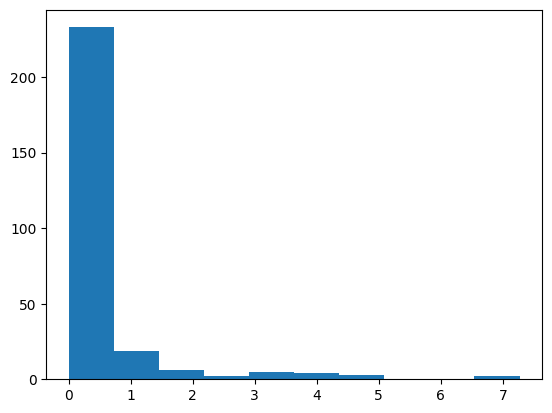

In [5]:
plt.hist(data["barrier_pre_flip"].item()["spatial_info_bps"])

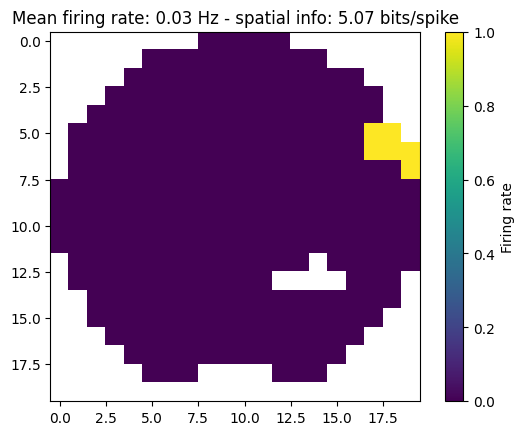

In [40]:
# find the ones above 0.5 bits per spike
place_cells = np.where(data["barrier_pre_flip"].item()["spatial_info_bps"] > 0.5)[0]
i=24
rate_map = data["barrier_pre_flip"].item()["rate_map"][:,:,place_cells[i]]
occupancy_map = data["barrier_pre_flip"].item()["occupancy_map"]
valid = ~np.isnan(rate_map) & ~np.isnan(occupancy_map)
rate = rate_map[valid]
occupancy = occupancy_map[valid]
p_i = occupancy / np.sum(occupancy)
mean_rate = np.sum(p_i * rate)
plt.imshow(data["barrier_pre_flip"].item()["rate_map"][:,:,place_cells[i]])
plt.title(f"Mean firing rate: {mean_rate:.2f} Hz - spatial info: {data['barrier_pre_flip'].item()['spatial_info_bps'][place_cells[i]]:.2f} bits/spike")
plt.colorbar(label="Firing rate")